# Display D-vs-T Heatmap Results

This notebook reads a fixed-c success matrix and overlays the theoretical `D_min` line. The preset `c` is a uniform experimental threshold, not an estimate of the actual contraction rate.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

%matplotlib inline

## Parameters

These values should match the parameters used when generating the heatmap files.

In [ ]:
# File name parameters
n = 100
q = 0.8
beta = 0.01
D_min = 1
D_max = 30
c = 0.01
num_samples = 100
T_intervals = 100
T_max = 20000
#corruption_type = "oblivious_large"
corruption_type = "adversarial"
#corruption_type = "sup_c"

## Locate Files

In [36]:
notebook_dir = Path.cwd()
if notebook_dir.name == "heatmap_data_display":
    repo_root = notebook_dir.parent
else:
    repo_root = notebook_dir

data_dir = repo_root / "heat_map_raw_data"
beta_for_filename = np.floor(beta * 100) / 100

base_suffix = (
    f"__n={n}"
    f"__q={q * 100:.0f}"
    f"__beta={beta_for_filename * 100:.0f}"
    f"__D_min={D_min}"
    f"__D_max={D_max}"
    f"__c={c:1.0e}"
    f"__num_samples={num_samples}"
    f"__T_intervals={T_intervals}"
    f"__T_max={T_max}"
    f"__corruption_type={corruption_type}"
)

success_path = data_dir / f"D_vs_T{base_suffix}.txt"
d_min_path = data_dir / f"D_vs_T__D_MIN{base_suffix}.txt"

print("success_path:", success_path)
print("d_min_path:", d_min_path)
for path in (success_path, d_min_path):
    if not path.exists():
        raise FileNotFoundError(path)

success_path: /Users/wutong/Documents/LearningNote/PRKm/68712762506e6475ec091584/codes/adv_D_upper/heat_map_raw_data/D_vs_T__n=100__q=80__beta=1__D_min=1__D_max=30__c=1e-02__num_samples=10__T_intervals=1000__T_max=20000__corruption_type=adversarial.txt
d_min_path: /Users/wutong/Documents/LearningNote/PRKm/68712762506e6475ec091584/codes/adv_D_upper/heat_map_raw_data/D_vs_T__D_MIN__n=100__q=80__beta=1__D_min=1__D_max=30__c=1e-02__num_samples=10__T_intervals=1000__T_max=20000__corruption_type=adversarial.txt


If the exact parameters do not match, this helper lists existing D-vs-T result files.

In [37]:
result_files = sorted(path.name for path in data_dir.glob("D_vs_T*.txt"))
if pd is not None:
    display(pd.DataFrame({"file": result_files}))
else:
    for name in result_files:
        print(name)

,file
0,D_vs_T__D_MIN__n=100__q=80__beta=1__D_min=1__D...
1,D_vs_T__D_MIN__n=100__q=80__beta=1__D_min=1__D...
2,D_vs_T__D_MIN__n=100__q=80__beta=1__D_min=1__D...
3,D_vs_T__D_MIN__n=100__q=80__beta=1__D_min=1__D...
4,D_vs_T__n=100__q=80__beta=1__D_min=1__D_max=30...
5,D_vs_T__n=100__q=80__beta=1__D_min=1__D_max=30...
6,D_vs_T__n=100__q=80__beta=1__D_min=1__D_max=30...
7,D_vs_T__n=100__q=80__beta=1__D_min=1__D_max=30...


## Load Data

In [38]:
success = np.atleast_2d(np.loadtxt(success_path))
d_min_vals = np.ravel(np.loadtxt(d_min_path))

T_values = np.arange(T_intervals, T_max + T_intervals, T_intervals)
D_values = np.arange(D_min, D_max + 1)

print("success shape:", success.shape)
print("D_min shape:", d_min_vals.shape)

success shape: (30, 20)
D_min shape: (20,)


## Success Heatmap

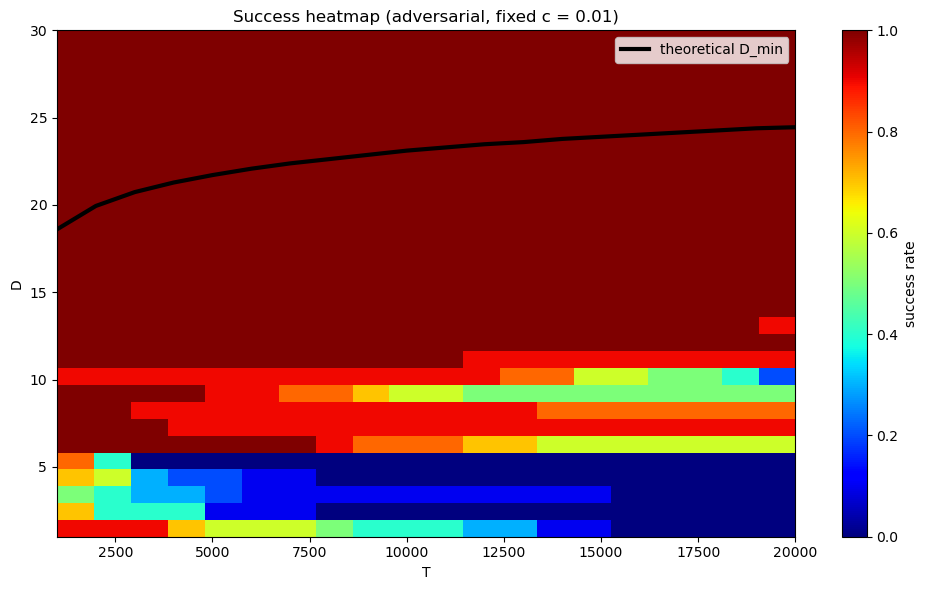

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(
    success,
    aspect="auto",
    origin="lower",
    extent=[T_values[0], T_values[-1], D_values[0], D_values[-1]],
    vmin=0,
    vmax=1,
    cmap="jet",
)
ax.plot(T_values, d_min_vals, linewidth=3, color="black", label="theoretical D_min")
fig.colorbar(image, ax=ax, label="success rate")
ax.set_title(f"Success heatmap ({corruption_type}, fixed c = {c:g})")
ax.set_xlabel("T")
ax.set_ylabel("D")
ax.legend()
plt.tight_layout()

## Quick Numeric Summaries

In [ ]:
print("success min/mean/max:", np.nanmin(success), np.nanmean(success), np.nanmax(success))
print("D_min min/max:", np.nanmin(d_min_vals), np.nanmax(d_min_vals))